<a href="https://colab.research.google.com/github/ManuJLV/PracticasIA/blob/main/Rna_dermatology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn import datasets
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
names_list = ["erythema","scaling","definite_borders","itching","koebner_phenomenon",
              "polygonal_papules","follicular_papules","oral_mucosal_involvement",
              "knee_and_elbow_involvement","scalp_involvement","family_history",
              "melanin_incontinence","eosinophils_in_the_infiltrate","PNL_infiltrate",
              "fibrosis_of_the_papillary_dermis","exocytosis","acanthosis",
              "hyperkeratosis","parakeratosis","clubbing_of_the_rete_ridges",
              "elongation_of_the_rete_ridges","thinning_of_the_suprapapillary_epidermis",
              "spongiform_pustule","munro_microabcess","focal_hypergranulosis",
              "disappearance_of_the_granular_layer","vacuolisation_and_damage_of_basal_layer",
              "spongiosis","saw-tooth_appearance_of_retes","follicular_horn_plug",
              "perifollicular_parakeratosis","inflammatory_monoluclear_inflitrate",
              "band-like_infiltrate","Age", "class"]
#print(len(names_list))
na_values = ['?']
dermatology = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/dermatology/dermatology.data", sep=",",na_values = na_values,header=None, names=names_list)
dermatology.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


In [ ]:
dermatology.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [ ]:
#dermatology.dropna(subset=["Age"], inplace=True)
#dermatology.isnull().sum()

In [ ]:
age_media = dermatology["Age"].mean()


l_input = ["erythema","scaling","definite_borders","itching","koebner_phenomenon",
              "follicular_papules","oral_mucosal_involvement",
              "knee_and_elbow_involvement","scalp_involvement","family_history",
              "eosinophils_in_the_infiltrate","PNL_infiltrate",
              "fibrosis_of_the_papillary_dermis","exocytosis","acanthosis",
              "hyperkeratosis","parakeratosis","clubbing_of_the_rete_ridges",
              "elongation_of_the_rete_ridges","thinning_of_the_suprapapillary_epidermis",
              "spongiform_pustule","munro_microabcess","focal_hypergranulosis",
              "disappearance_of_the_granular_layer",
              "spongiosis","saw-tooth_appearance_of_retes","follicular_horn_plug",
              "perifollicular_parakeratosis","inflammatory_monoluclear_inflitrate",
              "band-like_infiltrate","Age"]

In [ ]:
dermatology["Age"].fillna(age_media, inplace=True)
dermatology.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [ ]:
#Tarea
#1: Sacar el promedio(edad) por clase(salida) panda trae la funcion group by, reemplazar el valor desconocido segun su clase por el promedio
  #También se puede reemplazar por la moda

In [ ]:
correlation=dermatology.corr()
correlation.to_csv('cor.csv')

In [ ]:
"""train, test = train_test_split(dermatology, test_size=0.3)
print(len(train))
print(len(test))"""

'train, test = train_test_split(dermatology, test_size=0.3)\nprint(len(train))\nprint(len(test))'

In [ ]:
input = dermatology[:31]
output = dermatology["class"]
np_input = input.to_numpy()
np_output = output.to_numpy()

In [ ]:
onehot_encoder=OneHotEncoder(sparse=False)
reshaped=np_output.reshape(len(np_output), 1)
onehot=onehot_encoder.fit_transform(reshaped)
print(onehot[:6])

[[0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]


In [ ]:
col_name = ["c1","c2","c3","c4","c5","c6"]
df_output = pd.DataFrame(onehot, columns=col_name)
print(df_output.head())

    c1   c2   c3   c4   c5   c6
0  0.0  1.0  0.0  0.0  0.0  0.0
1  1.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  1.0  0.0  0.0  0.0
3  1.0  0.0  0.0  0.0  0.0  0.0
4  0.0  0.0  1.0  0.0  0.0  0.0


In [ ]:
df_input = dermatology[l_input]

In [ ]:
dataset= pd.concat([df_input, df_output], axis=1)
dataset.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,...,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,c1,c2,c3,c4,c5,c6
0,2,2,0,3,0,0,0,1,0,0,...,0,1,0,55.0,0.0,1.0,0.0,0.0,0.0,0.0
1,3,3,3,2,1,0,0,1,1,1,...,0,1,0,8.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,1,2,3,1,0,3,0,0,0,...,0,2,3,26.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2,2,2,0,0,0,0,3,2,0,...,0,3,0,40.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2,3,2,2,2,0,2,0,0,0,...,0,2,3,45.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
train, test = train_test_split(dataset, test_size=0.3)

In [ ]:
x_train = train[l_input]
y_train = train[col_name]

x_test = test[l_input]
y_test = test[col_name]
y_test.head()

,c1,c2,c3,c4,c5,c6
347,0.0,0.0,0.0,0.0,0.0,1.0
145,0.0,0.0,1.0,0.0,0.0,0.0
138,0.0,0.0,1.0,0.0,0.0,0.0
362,0.0,0.0,0.0,1.0,0.0,0.0
51,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
classifier = MLPClassifier(solver='adam', activation='relu', alpha=1e-12,tol=1e-18,
                    hidden_layer_sizes=(31,18,6),learning_rate='constant',
                    learning_rate_init=0.001, max_iter=500, momentum=0.9, verbose=True)

classifier.fit(x_train,y_train)

Iteration 1, loss = 8.00957985
Iteration 2, loss = 7.21697418
Iteration 3, loss = 6.48252649
Iteration 4, loss = 5.80223429
Iteration 5, loss = 5.21147342
Iteration 6, loss = 4.68274925
Iteration 7, loss = 4.24223747
Iteration 8, loss = 3.88299989
Iteration 9, loss = 3.61086905
Iteration 10, loss = 3.40895048
Iteration 11, loss = 3.25863860
Iteration 12, loss = 3.14623451
Iteration 13, loss = 3.05101493
Iteration 14, loss = 2.96423471
Iteration 15, loss = 2.88705451
Iteration 16, loss = 2.80965377
Iteration 17, loss = 2.73758243
Iteration 18, loss = 2.68143357
Iteration 19, loss = 2.62028006
Iteration 20, loss = 2.56805498
Iteration 21, loss = 2.51992793
Iteration 22, loss = 2.47286321
Iteration 23, loss = 2.42856677
Iteration 24, loss = 2.38430003
Iteration 25, loss = 2.34293362
Iteration 26, loss = 2.30179937
Iteration 27, loss = 2.26539492
Iteration 28, loss = 2.23358929
Iteration 29, loss = 2.20315472
Iteration 30, loss = 2.17137050
Iteration 31, loss = 2.13909784
Iteration 32, los

/usr/local/lib/python3.8/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(alpha=1e-12, hidden_layer_sizes=(31, 18, 6), max_iter=500,
              tol=1e-18, verbose=True)

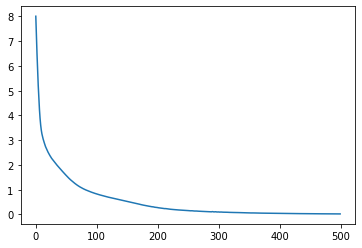

In [ ]:
plt.plot(classifier.loss_curve_)

In [ ]:
test_pred=classifier.predict(x_test)
#print(test_pred)
#print(len(y_test))
#print(len(test_pred))
#print(test_pred)

In [ ]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       0.83      0.95      0.88        20
           2       1.00      1.00      1.00        18
           3       0.94      0.81      0.87        21
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00         6

   micro avg       0.95      0.95      0.95       110
   macro avg       0.96      0.96      0.96       110
weighted avg       0.96      0.95      0.95       110
 samples avg       0.95      0.95      0.95       110



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
cm= multilabel_confusion_matrix(y_test, test_pred)
print(cm)
#guardar redNeuronal ya entrenada

[[[ 81   0]
  [  0  29]]

 [[ 86   4]
  [  1  19]]

 [[ 92   0]
  [  0  18]]

 [[ 88   1]
  [  4  17]]

 [[ 94   0]
  [  0  16]]

 [[104   0]
  [  0   6]]]
